In [1]:
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 100.2 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os

print(os.path.exists("/content/drive/MyDrive"))
print(os.listdir("/content/drive/MyDrive")[:20])

PROJECT_DIR = "/content/drive/MyDrive/Cancer Evolution Arena"
DATA_DIR = f"{PROJECT_DIR}/Data"
RESULTS_DIR = f"{DATA_DIR}/Results"

for file in os.listdir(RESULTS_DIR):
    print(file)

Mounted at /content/drive
True
['Classroom', 'Chrome Syncable FileSystem', 'Screencastify', 'Saved from Chrome', 'Debate Feb 2025', 'Medcorps Officer Application: Rishabh Bhattiprolu.gdoc', 'Colab Notebooks', 'Bollywood Member List.gdoc', 'UnitedForDiabetes.gdoc', 'UnitedForDiabetes Officer Application (File responses)', 'IMG_1407.HEIC', 'Untitled document (30).gdoc', 'image (2).jpg', 'hey.gdoc', 'ASDRP App 2025.gdoc', 'image (1).jpg', 'image.jpg', 'MASTER COPY - AI Ethics Workshop (Do not edit).pptx', 'United4Diabetes Officer Interviews.gsheet', 'ThinkNeuro Article Analysis.gdoc']
notebook08_simulation_results.csv
notebook09_simulator_validation_results.csv
notebook09_validation_summary.csv
notebook07_all_progression_tests.csv
notebook07_inferred_progression_edges.csv
notebook07_progression_graph.graphml
cancer_evolution_arena_macro_map.html
tp53_branching_forecast.html
braf_branching_forecast.html
erbb4_branching_forecast.html
kras_branching_forecast.html
global_cancer_evolution_aren

In [5]:
import pandas as pd

progression_path = (
    "/content/drive/MyDrive/Cancer Evolution Arena/"
    "Data/Results/notebook07_inferred_progression_edges.csv"
)

progression_edges = pd.read_csv(progression_path)

print(progression_edges.shape)
progression_edges.head()

(32, 10)


,From,To,P_From,P_To,P_To_given_From,P_To_given_Not_From,Probability_Gain,CoOccurrence,OddsRatio,PValue
0,ATR,NTRK2,0.047826,0.043478,0.272727,0.031963,0.240764,3,11.357143,0.008194
1,BRAF,PIK3CA,0.095652,0.073913,0.272727,0.052885,0.219843,6,6.715909,0.002373
2,ALK,NTRK3,0.100000,0.091304,0.260870,0.072464,0.188406,6,4.517647,0.010199
3,ERBB4,SMARCA4,0.100000,0.056522,0.217391,0.038647,0.178744,5,6.909722,0.004841
4,NF1,NTRK3,0.130435,0.091304,0.233333,0.070000,0.163333,7,4.043478,0.010019


In [7]:
import networkx as nx
G_mut = nx.DiGraph()

for _, row in progression_edges.iterrows():
    G_mut.add_edge(
        row["From"],
        row["To"],
        weight=row["Probability_Gain"],
        odds_ratio=row["OddsRatio"],
        p_value=row["PValue"],
        cooccurrence=row["CoOccurrence"]
    )

print("Mutation graph nodes:", G_mut.number_of_nodes())
print("Mutation graph edges:", G_mut.number_of_edges())

Mutation graph nodes: 30
Mutation graph edges: 32


In [8]:
def build_state_path(start_gene, max_depth=3):
    paths = []

    def dfs(current_gene, current_state, path_score, depth):
        if depth == max_depth or current_gene not in G_mut:
            paths.append({
                "State": " + ".join(sorted(current_state)),
                "Genes": sorted(current_state),
                "Score": path_score
            })
            return

        successors = list(G_mut.successors(current_gene))

        if len(successors) == 0:
            paths.append({
                "State": " + ".join(sorted(current_state)),
                "Genes": sorted(current_state),
                "Score": path_score
            })
            return

        for next_gene in successors:
            if next_gene in current_state:
                continue

            edge = G_mut[current_gene][next_gene]
            new_state = set(current_state)
            new_state.add(next_gene)

            dfs(
                next_gene,
                new_state,
                path_score * edge["weight"],
                depth + 1
            )

    dfs(start_gene, set([start_gene]), 1.0, 0)

    return pd.DataFrame(paths).sort_values(
        "Score",
        ascending=False
    )

In [9]:
build_state_path("KRAS", max_depth=3)

,State,Genes,Score
2,KRAS + STAT5B,"[KRAS, STAT5B]",0.040000
0,ATM + KRAS + STK11,"[ATM, KRAS, STK11]",0.023820
1,KRAS + NTRK1 + RBM10,"[KRAS, NTRK1, RBM10]",0.013161


In [10]:
build_state_path("TP53", max_depth=3)

,State,Genes,Score
0,NTRK3 + TP53,"[NTRK3, TP53]",0.143834
6,EGFR + TP53,"[EGFR, TP53]",0.099916
8,RET + TP53,"[RET, TP53]",0.075982
9,NTRK2 + TP53,"[NTRK2, TP53]",0.075982
10,RB1 + TP53,"[RB1, TP53]",0.058506
12,CDKN2A + TP53,"[CDKN2A, TP53]",0.058506
13,NOTCH2 + TP53,"[NOTCH2, TP53]",0.058506
11,ROS1 + TP53,"[ROS1, TP53]",0.058506
3,ALK + NTRK3 + TP53,"[ALK, NTRK3, TP53]",0.020743
7,ATR + NTRK2 + TP53,"[ATR, NTRK2, TP53]",0.020544


In [11]:
build_state_path("KEAP1", max_depth=3)

,State,Genes,Score
0,CTNNB1 + KEAP1,"[CTNNB1, KEAP1]",0.103947
1,KEAP1 + STAT3,"[KEAP1, STAT3]",0.064474
2,KEAP1 + RIT1,"[KEAP1, RIT1]",0.064474


In [12]:
print(progression_edges.columns.tolist())

['From', 'To', 'P_From', 'P_To', 'P_To_given_From', 'P_To_given_Not_From', 'Probability_Gain', 'CoOccurrence', 'OddsRatio', 'PValue']


In [13]:
state_graph = nx.DiGraph()

start_genes = ["KRAS", "TP53", "KEAP1", "BRAF", "ERBB4"]

for start in start_genes:
    branches = []

    def dfs(current_gene, current_state, ordered_path, path_score, depth):
        if depth == 3 or current_gene not in G_mut:
            branches.append((ordered_path, path_score))
            return

        successors = list(G_mut.successors(current_gene))

        if len(successors) == 0:
            branches.append((ordered_path, path_score))
            return

        for next_gene in successors:
            if next_gene in current_state:
                continue

            edge = G_mut[current_gene][next_gene]

            dfs(
                next_gene,
                current_state | {next_gene},
                ordered_path + [next_gene],
                path_score * edge["weight"],
                depth + 1
            )

    dfs(start, {start}, [start], 1.0, 0)

    for path, score in branches:
        for i in range(1, len(path)):
            previous_state = " + ".join(path[:i])
            next_state = " + ".join(path[:i+1])

            state_graph.add_edge(
                previous_state,
                next_state,
                weight=score
            )

print("State nodes:", state_graph.number_of_nodes())
print("State edges:", state_graph.number_of_edges())

list(state_graph.edges(data=True))[:20]

State nodes: 36
State edges: 31


[('KRAS', 'KRAS + STK11', {'weight': 0.023820033955857387}),
 ('KRAS', 'KRAS + RBM10', {'weight': 0.013161290322580637}),
 ('KRAS', 'KRAS + STAT5B', {'weight': 0.04}),
 ('KRAS + STK11', 'KRAS + STK11 + ATM', {'weight': 0.023820033955857387}),
 ('KRAS + RBM10', 'KRAS + RBM10 + NTRK1', {'weight': 0.013161290322580637}),
 ('TP53', 'TP53 + NTRK3', {'weight': 0.1438340551629815}),
 ('TP53', 'TP53 + NF1', {'weight': 0.012719398222019592}),
 ('TP53', 'TP53 + ALK', {'weight': 0.011701238507712167}),
 ('TP53', 'TP53 + EGFR', {'weight': 0.0999164197249449}),
 ('TP53', 'TP53 + ATR', {'weight': 0.020543860656772082}),
 ('TP53', 'TP53 + RET', {'weight': 0.0759820682318972}),
 ('TP53', 'TP53 + NTRK2', {'weight': 0.0759820682318972}),
 ('TP53', 'TP53 + RB1', {'weight': 0.0585061925385608}),
 ('TP53', 'TP53 + ROS1', {'weight': 0.0585061925385608}),
 ('TP53', 'TP53 + CDKN2A', {'weight': 0.0585061925385608}),
 ('TP53', 'TP53 + NOTCH2', {'weight': 0.0585061925385608}),
 ('TP53 + NF1', 'TP53 + NF1 + NTRK3

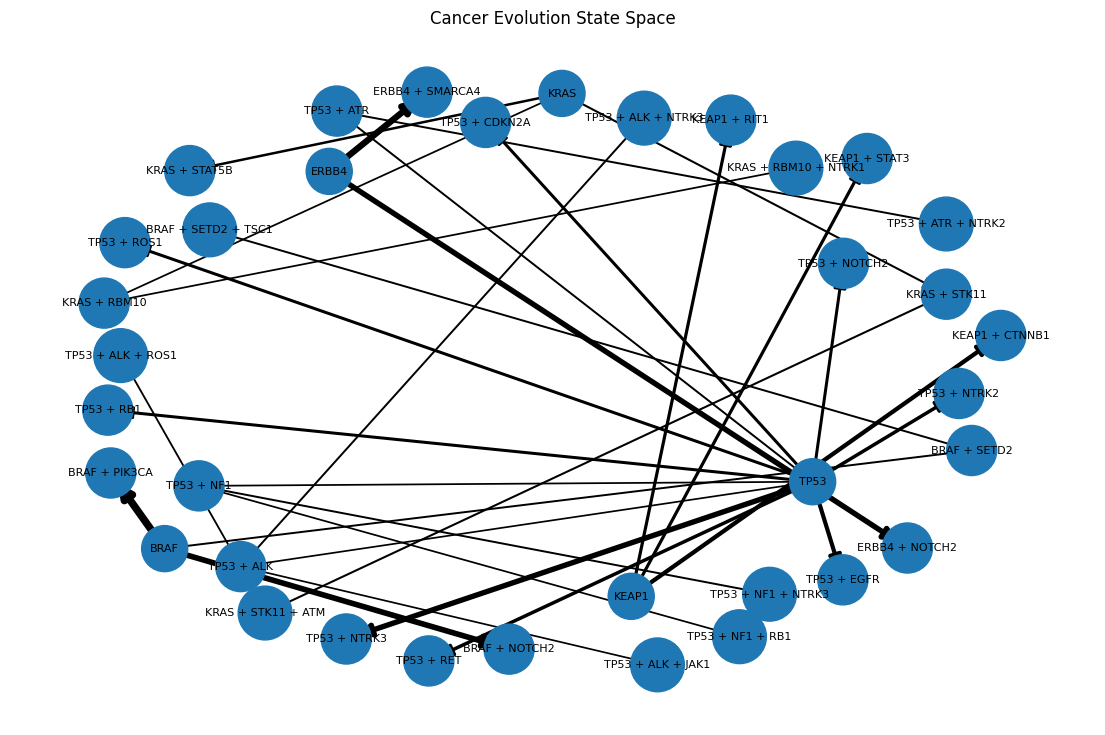

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 9))

pos = nx.spring_layout(state_graph, seed=42, k=0.9)

node_sizes = [
    900 + 200 * len(node.split(" + "))
    for node in state_graph.nodes()
]

edge_widths = [
    1 + 20 * state_graph[u][v]["weight"]
    for u, v in state_graph.edges()
]

nx.draw_networkx_nodes(
    state_graph,
    pos,
    node_size=node_sizes
)

nx.draw_networkx_edges(
    state_graph,
    pos,
    arrows=True,
    arrowsize=18,
    width=edge_widths
)

nx.draw_networkx_labels(
    state_graph,
    pos,
    font_size=8
)

plt.title("Cancer Evolution State Space")
plt.axis("off")
plt.show()

In [15]:
nx.write_graphml(
    state_graph,
    f"{RESULTS_DIR}/notebook10_evolutionary_state_space.graphml"
)

In [16]:
ecosystem_summary = pd.DataFrame([
    {
        "Ecosystem": "KRAS-STK11 Resistance Ecosystem",
        "Cluster": 0,
        "Defining Genes": "KRAS, STK11, KEAP1, RBM10",
        "Interpretation": "KRAS-dominant tumors enriched for STK11, KEAP1, and RBM10 alterations."
    },
    {
        "Ecosystem": "KEAP1 Stress-Adaptation Ecosystem",
        "Cluster": 1,
        "Defining Genes": "KEAP1, MET, CTNNB1, RIT1",
        "Interpretation": "KEAP1-enriched tumors with possible stress-response and signaling adaptation features."
    },
    {
        "Ecosystem": "TP53 Hub Ecosystem",
        "Cluster": 2,
        "Defining Genes": "TP53, NF1, PIK3CA, BRAF",
        "Interpretation": "TP53-dominant tumors with multiple secondary branching routes."
    },
    {
        "Ecosystem": "EGFR Driver Ecosystem",
        "Cluster": 3,
        "Defining Genes": "EGFR, TP53",
        "Interpretation": "EGFR-defined tumor state largely separate from the KRAS ecosystem."
    }
])

ecosystem_summary

,Ecosystem,Cluster,Defining Genes,Interpretation
0,KRAS-STK11 Resistance Ecosystem,0,"KRAS, STK11, KEAP1, RBM10","KRAS-dominant tumors enriched for STK11, KEAP1..."
1,KEAP1 Stress-Adaptation Ecosystem,1,"KEAP1, MET, CTNNB1, RIT1",KEAP1-enriched tumors with possible stress-res...
2,TP53 Hub Ecosystem,2,"TP53, NF1, PIK3CA, BRAF",TP53-dominant tumors with multiple secondary b...
3,EGFR Driver Ecosystem,3,"EGFR, TP53",EGFR-defined tumor state largely separate from...


In [17]:
ecosystem_summary.to_csv(
    f"{RESULTS_DIR}/notebook10_ecosystem_state_summary.csv",
    index=False
)

In [18]:
%whos

Variable            Type         Data/Info
------------------------------------------
DATA_DIR            str          /content/drive/MyDrive/Ca<...>ncer Evolution Arena/Data
G_mut               DiGraph      DiGraph with 30 nodes and 32 edges
PROJECT_DIR         str          /content/drive/MyDrive/Cancer Evolution Arena
RESULTS_DIR         str          /content/drive/MyDrive/Ca<...>lution Arena/Data/Results
branches            list         n=2
build_state_path    function     <function build_state_path at 0x79fe7fffb100>
dfs                 function     <function dfs at 0x79feb8e6a7a0>
drive               module       <module 'google.colab.dri<...>s/google/colab/drive.py'>
ecosystem_summary   DataFrame                             <...>argely separate from...  
edge_widths         list         n=31
file                str          notebook10_ecosystem_state_summary.csv
i                   int          1
next_state          str          ERBB4 + NOTCH2
node_sizes          list         n=3

In [19]:
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f)

braf_branching_forecast.html
cancer_evolution_arena_macro_map.html
ecosystem_annotated_cancer_evolution_arena.html
erbb4_branching_forecast.html
global_cancer_evolution_arena.html
kras_branching_forecast.html
notebook07_all_progression_tests.csv
notebook07_inferred_progression_edges.csv
notebook07_progression_graph.graphml
notebook08_simulation_results.csv
notebook09_simulator_validation_results.csv
notebook09_validation_summary.csv
notebook10_ecosystem_state_summary.csv
notebook10_evolutionary_state_space.graphml
tp53_branching_forecast.html


In [20]:
ecosystem_summary = pd.read_csv(
    f"{RESULTS_DIR}/notebook10_ecosystem_state_summary.csv"
)

ecosystem_summary

,Ecosystem,Cluster,Defining Genes,Interpretation
0,KRAS-STK11 Resistance Ecosystem,0,"KRAS, STK11, KEAP1, RBM10","KRAS-dominant tumors enriched for STK11, KEAP1..."
1,KEAP1 Stress-Adaptation Ecosystem,1,"KEAP1, MET, CTNNB1, RIT1",KEAP1-enriched tumors with possible stress-res...
2,TP53 Hub Ecosystem,2,"TP53, NF1, PIK3CA, BRAF",TP53-dominant tumors with multiple secondary b...
3,EGFR Driver Ecosystem,3,"EGFR, TP53",EGFR-defined tumor state largely separate from...


In [21]:
state_space_bridge = pd.DataFrame([
    {
        "Mutation Trajectory": "KRAS → KRAS + STK11 → KRAS + STK11 + ATM",
        "Ecosystem Interpretation": "KRAS-STK11 Resistance Ecosystem",
        "Why It Matters": "Suggests a KRAS-centered progression route toward STK11-associated resistance and DNA repair dysfunction."
    },
    {
        "Mutation Trajectory": "KEAP1 → KEAP1 + CTNNB1",
        "Ecosystem Interpretation": "KEAP1 Stress-Adaptation Ecosystem",
        "Why It Matters": "Links KEAP1-altered tumors to WNT/stress-adaptation signaling features."
    },
    {
        "Mutation Trajectory": "TP53 → TP53 + NF1",
        "Ecosystem Interpretation": "TP53 Hub Ecosystem",
        "Why It Matters": "Shows TP53 acting as a central branching hub for secondary pathway disruption."
    },
    {
        "Mutation Trajectory": "TP53 → TP53 + EGFR",
        "Ecosystem Interpretation": "EGFR Driver Ecosystem",
        "Why It Matters": "Represents a distinct EGFR-associated tumor state separate from the KRAS ecosystem."
    }
])

state_space_bridge

,Mutation Trajectory,Ecosystem Interpretation,Why It Matters
0,KRAS → KRAS + STK11 → KRAS + STK11 + ATM,KRAS-STK11 Resistance Ecosystem,Suggests a KRAS-centered progression route tow...
1,KEAP1 → KEAP1 + CTNNB1,KEAP1 Stress-Adaptation Ecosystem,Links KEAP1-altered tumors to WNT/stress-adapt...
2,TP53 → TP53 + NF1,TP53 Hub Ecosystem,Shows TP53 acting as a central branching hub f...
3,TP53 → TP53 + EGFR,EGFR Driver Ecosystem,Represents a distinct EGFR-associated tumor st...


In [22]:
state_space_bridge.to_csv(
    f"{RESULTS_DIR}/notebook10_state_space_bridge.csv",
    index=False
)